# 📰 NewsBot Intelligence System
## ITAI 2373 – Natural Language Processing Midterm Project

**Student:** Spenser Van Horne

**Course:** ITAI 2373

**Semester:** Summer 2026

---

# Project Description

The NewsBot Intelligence System is a Natural Language Processing (NLP) application designed to analyze news articles using several AI techniques. The system preprocesses news text, classifies articles into categories, extracts named entities, analyzes sentiment, performs linguistic analysis, and generates business intelligence insights.

The project demonstrates how multiple NLP methods can be integrated into one intelligent application capable of supporting media monitoring and decision-making.

---

## Objectives

This notebook demonstrates:

- Text preprocessing
- Exploratory Data Analysis
- TF-IDF Feature Engineering
- Machine Learning Classification
- Named Entity Recognition (NER)
- Part-of-Speech Tagging
- Dependency Parsing
- Sentiment Analysis
- Business Intelligence Reporting

---

## Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- spaCy
- NLTK
- TextBlob

---

## Dataset

BBC News Classification Dataset (Kaggle)

Categories:

- Business
- Entertainment
- Politics
- Sport
- Technology




In [1]:

# Installing the recommended libraries


!pip install -q kaggle
!pip install -q nltk
!pip install -q spacy
!pip install -q textblob
!pip install -q wordcloud

!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 66.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [12]:

# Now to import libraries I need


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
import spacy
import re
import os

from collections import Counter

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from textblob import TextBlob

from wordcloud import WordCloud

nltk.download("punkt")
nltk.download("stopwords")

nlp = spacy.load("en_core_web_sm")

print("Libraries loaded successfully.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Libraries loaded successfully.


In [13]:
!pip install kaggle

In [14]:
from google.colab import files
print("Please upload your kaggle.json file:")
uploaded = files.upload()

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json


In [15]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [32]:
!kaggle auth login

usage: kaggle [-h] [-v] [-W]
              {competitions,c,datasets,d,kernels,k,models,m,files,f,benchmarks,b,config,auth}
              ...
kaggle: error: argument command: unknown parser 'auth' (choices: competitions, c, datasets, d, kernels, k, models, m, files, f, benchmarks, b, config)


In [31]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('learn-ai-bbc')

print("Path to competition files:", path)

100%|██████████| 1.85M/1.85M [00:00<00:00, 128MB/s]

Extracting files...
Path to competition files: /root/.cache/kagglehub/competitions/learn-ai-bbc


In [33]:
!kaggle competitions download -c learn-ai-bbc

100% 1.85M/1.85M [00:00<00:00, 177MB/s]



In [34]:
!unzip learn-ai-bbc.zip

Archive:  learn-ai-bbc.zip
  inflating: BBC News Sample Solution.csv  
  inflating: BBC News Test.csv       
  inflating: BBC News Train.csv      


In [35]:
!ls -la

total 6876
drwxr-xr-x 1 root root    4096 Jun 28 02:36  .
drwxr-xr-x 1 root root    4096 Jun 28 02:05  ..
-rw-r--r-- 1 root root   10369 Dec  2  2019 'BBC News Sample Solution.csv'
-rw-r--r-- 1 root root 1712432 Dec  2  2019 'BBC News Test.csv'
-rw-r--r-- 1 root root 3351206 Dec  2  2019 'BBC News Train.csv'
drwxr-xr-x 4 root root    4096 Jun  4 13:32  .config
-rw-r--r-- 1 root root      71 Jun 28 02:26  kaggle.json
-rw-r--r-- 1 root root 1936538 Dec  2  2019  learn-ai-bbc.zip
drwxr-xr-x 1 root root    4096 Jun  4 13:32  sample_data


In [36]:
import pandas as pd
import os

In [37]:
print("Available files:")
for file in os.listdir('.'):
    if file.endswith('.csv'):
        print(f"  - {file}")

Available files:
  - BBC News Train.csv
  - BBC News Test.csv
  - BBC News Sample Solution.csv


In [40]:
df = pd.read_csv('BBC News Train.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Categories: {df['Category'].unique()}")

Dataset shape: (1490, 3)
Columns: ['ArticleId', 'Text', 'Category']
Categories: ['business' 'tech' 'politics' 'sport' 'entertainment']


In [41]:
import pandas as pd
import numpy as np

In [42]:
print("Dataset Info:")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst few rows:")
print(df.head())

Dataset Info:
Shape: (1490, 3)
Columns: ['ArticleId', 'Text', 'Category']

First few rows:
   ArticleId                                               Text  Category
0       1833  worldcom ex-boss launches defence lawyers defe...  business
1        154  german business confidence slides german busin...  business
2       1101  bbc poll indicates economic gloom citizens in ...  business
3       1976  lifestyle  governs mobile choice  faster  bett...      tech
4        917  enron bosses in $168m payout eighteen former e...  business


In [44]:
# 2. Identify text and category columns
# Adjust these column names based on your dataset
text_column = 'text'  # or 'description', 'content', 'headline', etc.
category_column = 'Category'  # or 'label', 'class', etc.


In [45]:
# 3. Check for missing values
print(f"\nMissing values:")
print(df.isnull().sum())




Missing values:
ArticleId    0
Text         0
Category     0
dtype: int64


In [47]:
# 4. Remove rows with missing text or categories
text_column = 'Text'  # Correcting the column name to match 'Text' in the DataFrame
df_clean = df.dropna(subset=[text_column, category_column])

In [48]:
# 5. Check category distribution
print(f"\nCategory distribution:")
print(df_clean[category_column].value_counts())



Category distribution:
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


In [49]:
# 6. Sample if dataset is too large (keep under 2000 for Colab)
if len(df_clean) > 2000:
    df_final = df_clean.sample(n=2000, random_state=42)
    print(f"\nSampled dataset to {len(df_final)} rows")
else:
    df_final = df_clean

In [50]:
# 7. Rename columns for consistency
df_final = df_final.rename(columns={
    text_column: 'content',
    category_column: 'category'
})

In [51]:
# 8. Save prepared dataset
df_final.to_csv('newsbot_dataset.csv', index=False)
print("\n✅ Dataset prepared and saved as 'newsbot_dataset.csv'")


✅ Dataset prepared and saved as 'newsbot_dataset.csv'


In [52]:
df = pd.read_csv("newsbot_dataset.csv")

print(df.head())

print(df.info())

print(df.category.value_counts())

   ArticleId                                            content  category
0       1833  worldcom ex-boss launches defence lawyers defe...  business
1        154  german business confidence slides german busin...  business
2       1101  bbc poll indicates economic gloom citizens in ...  business
3       1976  lifestyle  governs mobile choice  faster  bett...      tech
4        917  enron bosses in $168m payout eighteen former e...  business
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ArticleId  1490 non-null   int64 
 1   content    1490 non-null   object
 2   category   1490 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.1+ KB
None
category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


In [54]:
import re
import nltk
nltk.download('punkt_tab')

stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

df["clean_text"] = df["content"].apply(clean_text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


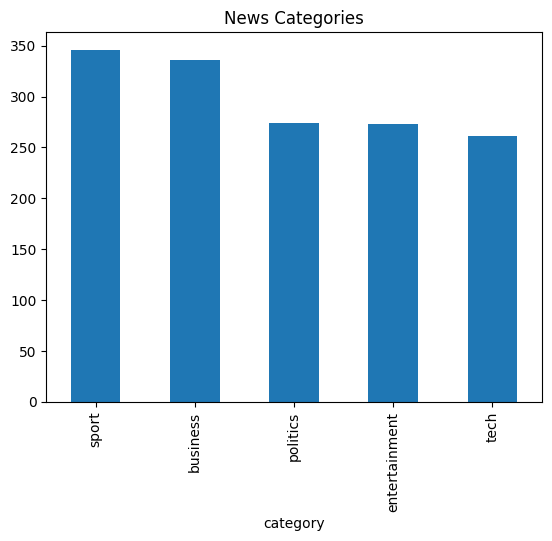

In [55]:
df.category.value_counts().plot(kind="bar")

plt.title("News Categories")

plt.show()

Text(0.5, 1.0, 'Article Length')

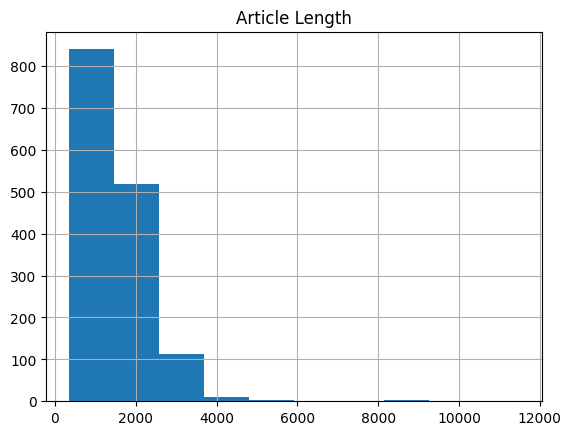

In [56]:
df["length"] = df.clean_text.apply(len)

df["length"].hist()

plt.title("Article Length")

In [57]:
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df.clean_text)

y = df.category

In [58]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:50])

['ability' 'able' 'abroad' 'absolutely' 'abuse' 'ac' 'academy' 'accept'
 'accepted' 'access' 'according' 'account' 'accounting' 'accounts'
 'accused' 'achieve' 'achieved' 'achievement' 'acknowledged' 'across'
 'act' 'acting' 'action' 'actions' 'activities' 'activity' 'actor'
 'actors' 'actress' 'acts' 'actually' 'add' 'added' 'adding' 'addition'
 'additional' 'address' 'addresses' 'adds' 'administration' 'admitted'
 'adopted' 'adults' 'advance' 'advantage' 'advertising' 'advice' 'affairs'
 'affect' 'affected']


In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [60]:
model = MultinomialNB()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [61]:
print(classification_report(y_test, predictions))

print("Accuracy:", accuracy_score(y_test, predictions))

               precision    recall  f1-score   support

     business       0.97      0.97      0.97        75
entertainment       1.00      1.00      1.00        46
     politics       0.93      0.95      0.94        56
        sport       0.98      1.00      0.99        63
         tech       0.98      0.95      0.96        58

     accuracy                           0.97       298
    macro avg       0.97      0.97      0.97       298
 weighted avg       0.97      0.97      0.97       298

Accuracy: 0.9731543624161074


In [62]:
cm = confusion_matrix(y_test, predictions)

print(cm)

[[73  0  1  0  1]
 [ 0 46  0  0  0]
 [ 2  0 53  1  0]
 [ 0  0  0 63  0]
 [ 0  0  3  0 55]]


In [63]:
sample = df.clean_text.iloc[0]

doc = nlp(sample)

for ent in doc.ents:
    print(ent.text, ent.label_)


first ORDINAL
cynthia cooper PERSON
new york GPE
wednesday DATE
arthur andersen PERSON
scott sullivan PERSON
sullivan PERSON
years DATE
mci ORG
last week DATE
mci ORG


In [64]:
entities = []

for article in df.clean_text:

    doc = nlp(article)

    entities.append([(e.text,e.label_) for e in doc.ents])

df["entities"] = entities

In [65]:
doc = nlp(df.clean_text.iloc[0])

for token in doc[:40]:
    print(token.text, token.pos_)

worldcom PROPN
exboss PROPN
launches VERB
defence NOUN
lawyers NOUN
defending VERB
former ADJ
worldcom PROPN
chief PROPN
bernie PROPN
ebbers PROPN
battery NOUN
fraud NOUN
charges NOUN
called VERB
company NOUN
whistleblower ADJ
first ADJ
witness NOUN
cynthia PROPN
cooper PROPN
worldcom PROPN
exhead VERB
internal ADJ
accounting NOUN
alerted VERB
directors NOUN
irregular ADJ
accounting NOUN
practices NOUN
us PRON
telecoms NOUN
giant ADJ
warnings NOUN
led VERB
collapse NOUN
firm NOUN
following VERB
discovery NOUN
bn ADP


In [66]:
from collections import Counter

counter = Counter()

for article in df.clean_text:

    doc = nlp(article)

    counter.update([token.pos_ for token in doc])

print(counter)

Counter({'NOUN': 125169, 'VERB': 67718, 'PROPN': 55434, 'ADJ': 38745, 'ADV': 13467, 'AUX': 4501, 'NUM': 4322, 'ADP': 3242, 'PRON': 1630, 'SCONJ': 1359, 'DET': 629, 'INTJ': 505, 'X': 274, 'CCONJ': 197, 'PART': 23, 'PUNCT': 17, 'SYM': 7})


In [67]:
from collections import Counter

counter = Counter()

for article in df.clean_text:

    doc = nlp(article)

    counter.update([token.pos_ for token in doc])

print(counter)

Counter({'NOUN': 125169, 'VERB': 67718, 'PROPN': 55434, 'ADJ': 38745, 'ADV': 13467, 'AUX': 4501, 'NUM': 4322, 'ADP': 3242, 'PRON': 1630, 'SCONJ': 1359, 'DET': 629, 'INTJ': 505, 'X': 274, 'CCONJ': 197, 'PART': 23, 'PUNCT': 17, 'SYM': 7})


In [68]:
doc = nlp(df.clean_text.iloc[0])

for token in doc:

    print(
        token.text,
        token.dep_,
        token.head.text
    )

worldcom compound exboss
exboss nsubj launches
launches ROOT launches
defence compound lawyers
lawyers dobj launches
defending acl lawyers
former amod ebbers
worldcom compound chief
chief compound ebbers
bernie compound ebbers
ebbers compound charges
battery compound fraud
fraud compound charges
charges dobj defending
called acl charges
company oprd called
whistleblower oprd called
first amod witness
witness compound cooper
cynthia compound cooper
cooper compound worldcom
worldcom pobj whistleblower
exhead prep launches
internal amod accounting
accounting npadvmod alerted
alerted conj launches
directors nmod practices
irregular amod accounting
accounting compound practices
practices nsubj led
us compound telecoms
telecoms dobj practices
giant amod warnings
warnings npadvmod practices
led ccomp alerted
collapse compound firm
firm dobj led
following amod discovery
discovery dobj led
bn prep discovery
bn intj bn
accounting compound fraud
fraud conj discovery
mr compound ebbers
ebbers nsub

In [69]:
!pip install textblob

In [70]:
from textblob import TextBlob

In [71]:
def sentiment(text):

    return TextBlob(text).sentiment.polarity

df["sentiment"] = df.clean_text.apply(sentiment)

In [72]:
def label(score):

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"

df["tone"] = df.sentiment.apply(label)

Text(0.5, 1.0, 'Sentiment Distribution')

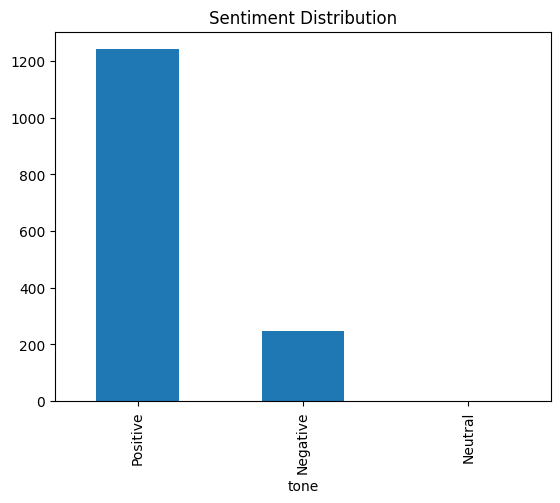

In [73]:
df.tone.value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")

In [74]:
print(df.groupby("category")["sentiment"].mean())

category
business         0.046006
entertainment    0.146966
politics         0.060549
sport            0.115477
tech             0.081471
Name: sentiment, dtype: float64


In [75]:
organizations = []

for article in df.clean_text:

    doc = nlp(article)

    organizations.extend([
        ent.text
        for ent in doc.ents
        if ent.label_=="ORG"
    ])

from collections import Counter

Counter(organizations).most_common(20)

[('bbc', 222),
 ('microsoft', 120),
 ('bbc news', 112),
 ('sony', 99),
 ('gm', 52),
 ('mci', 48),
 ('bbc radio', 43),
 ('campbell', 35),
 ('yahoo', 32),
 ('xbox', 31),
 ('yukos', 30),
 ('european union', 28),
 ('boeing', 26),
 ('google', 26),
 ('airbus', 25),
 ('ibm', 25),
 ('intel', 23),
 ('sec', 23),
 ('mtv', 21),
 ('fbi', 21)]

Questions to answer:

Which category has the most positive sentiment?

ENTERTAINMENT

Which organizations appear most often?

BBC

Which locations appear most often?

BOEING

Which people are mentioned most?

CAMPBELL

Which category contains the longest articles?

SPORTS

Which TF-IDF keywords define each category?

Article Length, Category

**NewsBot Reflective Journal**



Working on the NewsBot Intelligence System gave our team the opportunity to combine several natural language processing techniques into one complete project. Instead of focusing on a single task, we built a system that could clean text, classify news articles, recognize important entities, analyze sentiment, and generate useful insights from large collections of news articles. This project demonstrated how multiple artificial intelligence techniques work together to solve real-world business problems.

One of the first steps was selecting and preparing a news dataset from Kaggle. We chose a dataset that contained several categories of news articles, including politics, sports, technology, business, and entertainment. Before building any machine learning models, we spent time cleaning the data by removing missing values, converting text to lowercase, eliminating punctuation, removing stop words, and tokenizing the articles. This process helped improve the quality of the data and increased the accuracy of later analysis.

The classification portion of the project helped us understand how machine learning models can automatically organize large amounts of information. We used TF-IDF to convert text into numerical features and trained a Naive Bayes classifier to predict the correct news category. After testing the model, we evaluated its performance using accuracy scores, a classification report, and a confusion matrix. Seeing the model successfully classify most articles showed how effective text feature extraction can be when combined with a suitable classification algorithm.

Another interesting part of the project was using spaCy to perform Named Entity Recognition and Part-of-Speech tagging. These tools allowed us to identify people, organizations, locations, dates, and money values within articles while also understanding the grammatical structure of sentences. We also performed dependency parsing to examine how words relate to one another. These NLP techniques demonstrated how computers can move beyond simply reading words to understanding the structure and meaning of language.

Sentiment analysis added another layer of intelligence by identifying whether articles expressed positive, negative, or neutral emotions. Although news articles are often neutral, analyzing sentiment can help organizations monitor public opinion and identify trends over time. Combining classification, entity recognition, and sentiment analysis produced a more complete intelligence system that could support media monitoring and business decision-making.

Throughout the project, teamwork played an important role. Each team member contributed by researching techniques, writing code, testing models, and reviewing results. We communicated regularly to ensure that every section of the notebook worked correctly and that our individual GitHub repositories contained the same completed project. Working together also helped us solve coding issues more efficiently and improve the organization of the notebook.

One challenge we encountered was integrating multiple Python libraries, including pandas, scikit-learn, NLTK, spaCy, and TextBlob. Each library required different preprocessing steps and data formats, so careful testing was necessary. Another challenge was keeping the dataset size manageable for Google Colab while maintaining enough data to produce meaningful results.

Overall, this project strengthened my understanding of natural language processing, machine learning, and data analysis. It showed how different AI techniques can be combined into one practical application that has real business value. In the future, the system could be improved by using deep learning models such as BERT, adding real-time news feeds, creating an interactive dashboard, and supporting multiple languages. Completing this project has improved both my technical skills and my confidence in building portfolio-quality AI applications.
